**Depdendencies**

In [9]:
!pip install torchxrayvision
!pip install captum
!pip install kagglehub[pandas-datasets]

In [10]:
import os

SEED = 42

# Best set before importing torch / before any CUDA operation
os.environ["PYTHONHASHSEED"] = str(SEED)

# Needed for deterministic CUDA matmul behavior
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [11]:
import torch
import random
import numpy as np

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # cuDNN deterministic settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Disable TF32 for more reproducible floating point behavior
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False

    # Force deterministic algorithms where possible
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(SEED)

**The CheXpert Dataset**

In [12]:

import kagglehub

# Download cheXpert Dataset
path = kagglehub.dataset_download("ashery/chexpert")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/ashery/chexpert/versions/1


**Filter Dataset**

We want a balanced dataset, consisting of Pleural Effusion predictions only of a \~ 10k size.

In [13]:
import pandas as pd

# Load dataset
df = pd.read_csv(f"/{path}/train.csv")

# Keep only frontal images + valid labels (0 and 1)
df_pleural_effusion = df[
    (df["Frontal/Lateral"] == "Frontal") &
    (df["Pleural Effusion"].isin([0, 1]))
][["Path", "Pleural Effusion"]]

# Split by class
df_0 = df_pleural_effusion[df_pleural_effusion["Pleural Effusion"] == 0]
df_1 = df_pleural_effusion[df_pleural_effusion["Pleural Effusion"] == 1]

# Sample 25,000 from each class
df_0_sample = df_0.sample(n=5000, random_state=42)
df_1_sample = df_1.sample(n=5000, random_state=42)

# Combine and shuffle
df_balanced = pd.concat([df_0_sample, df_1_sample]) \
    .sample(frac=1, random_state=42) \
    .reset_index(drop=True)

df_balanced["Path"] = df_balanced["Path"].apply(lambda x: x.replace("CheXpert-v1.0-small", path))

# Verify distribution
print(df_balanced["Pleural Effusion"].value_counts())

# Final dataset preview
print(df_balanced.head())

Pleural Effusion
1.0    5000
0.0    5000
Name: count, dtype: int64
                                                Path  Pleural Effusion
0  /root/.cache/kagglehub/datasets/ashery/chexper...               1.0
1  /root/.cache/kagglehub/datasets/ashery/chexper...               0.0
2  /root/.cache/kagglehub/datasets/ashery/chexper...               0.0
3  /root/.cache/kagglehub/datasets/ashery/chexper...               0.0
4  /root/.cache/kagglehub/datasets/ashery/chexper...               0.0


In [14]:
del df_0_sample
del df_1_sample
del df_0
del df_1
del df_pleural_effusion
del df

**Load Dataset**

Loads and stores the images, and their TRUE labels.

In [15]:
from torch.utils.data import Dataset
import skimage.io
import torchxrayvision as xrv
import torchvision

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None):

        df = df.reset_index(drop=True)

        transform = transform = torchvision.transforms.Compose([
                                      xrv.datasets.XRayCenterCrop(),
                                      xrv.datasets.XRayResizer(224),
                                  ])

        images = []
        labels = []

        for i in range(len(df)):
            row = df.iloc[i]

            # load image once
            img = skimage.io.imread(row["Path"])

            # normalize
            img = xrv.datasets.normalize(img, 255)

            # add channel dimension
            img = img[None, ...]

            img = transform(img)

            # convert to tensor now (not in __getitem__)
            img = torch.from_numpy(np.array(img).astype(np.int16))

            images.append(img)

            label = torch.tensor(row["Pleural Effusion"]).float()
            labels.append(label)
            print(i)

        self.images = torch.stack(images)
        self.labels = torch.stack(labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx].float(), self.labels[idx]


dataset = ChestXrayDataset(df_balanced)

Streaming output truncated to the last 5000 lines.
5000
5001
5002
5003
5004
5005
5006
5007
5008
5009
5010
5011
5012
5013
5014
5015
5016
5017
5018
5019
5020
5021
5022
5023
5024
5025
5026
5027
5028
5029
5030
5031
5032
5033
5034
5035
5036
5037
5038
5039
5040
5041
5042
5043
5044
5045
5046
5047
5048
5049
5050
5051
5052
5053
5054
5055
5056
5057
5058
5059
5060
5061
5062
5063
5064
5065
5066
5067
5068
5069
5070
5071
5072
5073
5074
5075
5076
5077
5078
5079
5080
5081
5082
5083
5084
5085
5086
5087
5088
5089
5090
5091
5092
5093
5094
5095
5096
5097
5098
5099
5100
5101
5102
5103
5104
5105
5106
5107
5108
5109
5110
5111
5112
5113
5114
5115
5116
5117
5118
5119
5120
5121
5122
5123
5124
5125
5126
5127
5128
5129
5130
5131
5132
5133
5134
5135
5136
5137
5138
5139
5140
5141
5142
5143
5144
5145
5146
5147
5148
5149
5150
5151
5152
5153
5154
5155
5156
5157
5158
5159
5160
5161
5162
5163
5164
5165
5166
5167
5168
5169
5170
5171
5172
5173
5174
5175
5176
5177
5178
5179
5180
5181
5182
5183
5184
5185
5186
5187
5188
5189

In [16]:
del df_balanced

In [17]:
def get_disease_logits(model, imgs, disease):
    model.eval()
    model.op_threshs = None
    return model(imgs)[:,model.pathologies.index(disease)]

In [18]:
def get_all_logits(model, dataloader, disease, device):
    all_logits = []

    model.to(device)

    with torch.no_grad():
        i = 0
        for imgs, _ in dataloader:
            imgs = imgs.to(device)
            logits = get_disease_logits(model, imgs, disease)
            all_logits.append(logits.to("cpu"))
            print(f"batch {i}")
            i += 1

    model.to("cpu")
    return torch.cat(all_logits, dim=0)

In [19]:
def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_generator(seed=42):
    g = torch.Generator()
    g.manual_seed(seed)
    return g

In [20]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=1024,
    shuffle=False,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=make_generator(SEED)
)

model = xrv.models.DenseNet(weights="densenet121-res224-all")

logit_pred = get_all_logits(model, dataloader, "Effusion", device="cuda")

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]
batch 0
batch 1
batch 2
batch 3
batch 4
batch 5
batch 6
batch 7
batch 8
batch 9


In [21]:
def print_best_thresholds(y_true, logit_pred, num_thresholds=1001, eps=1e-8):
    """
    y_true: tensor/list of 0s and 1s
    logit_pred: raw model logits, not sigmoid probabilities
    """

    y_true = torch.as_tensor(y_true).float().view(-1)
    logit_pred = torch.as_tensor(logit_pred).float().view(-1)

    probs = torch.sigmoid(logit_pred)

    thresholds = torch.linspace(0, 1, num_thresholds)

    best = {
        "accuracy": (-1, None),
        "precision": (-1, None),
        "recall": (-1, None),
        "f1": (-1, None),
        "specificity": (-1, None),
        "balanced_accuracy": (-1, None),
        "youden_j": (-1, None),
    }

    for t in thresholds:
        y_pred = (probs >= t).float()

        tp = ((y_pred == 1) & (y_true == 1)).sum().float()
        tn = ((y_pred == 0) & (y_true == 0)).sum().float()
        fp = ((y_pred == 1) & (y_true == 0)).sum().float()
        fn = ((y_pred == 0) & (y_true == 1)).sum().float()

        accuracy = (tp + tn) / (tp + tn + fp + fn + eps)
        precision = tp / (tp + fp + eps)
        recall = tp / (tp + fn + eps)
        specificity = tn / (tn + fp + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        balanced_accuracy = (recall + specificity) / 2
        youden_j = recall + specificity - 1

        metrics = {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "specificity": specificity,
            "balanced_accuracy": balanced_accuracy,
            "youden_j": youden_j,
        }

        for name, value in metrics.items():
            value = value.item()
            if value > best[name][0]:
                best[name] = (value, t.item())

    print("Best thresholds:")
    print("-" * 45)
    for metric, (score, threshold) in best.items():
        print(f"{metric:20s} threshold = {threshold:.4f}, score = {score:.4f}")

In [22]:
y_true = dataset.labels
print_best_thresholds(y_true, logit_pred)
y_teacher_soft = torch.sigmoid(logit_pred)
y_teacher_hard = (y_teacher_soft >= 0.7150).float()

Best thresholds:
---------------------------------------------
accuracy             threshold = 0.7150, score = 0.8737
precision            threshold = 0.9890, score = 1.0000
recall               threshold = 0.0000, score = 1.0000
f1                   threshold = 0.7020, score = 0.8779
specificity          threshold = 0.9890, score = 1.0000
balanced_accuracy    threshold = 0.7150, score = 0.8737
youden_j             threshold = 0.7150, score = 0.7474


In [23]:
torch.cuda.empty_cache()

In [24]:
from captum.attr import (
    IntegratedGradients,
    DeepLift,
    GradientShap,
    LayerGradCam,
    LayerAttribution
)
import torch.nn as nn

class WrappedModel(nn.Module):
    def __init__(self, model, target_idx):
        super().__init__()
        self.model = model
        self.target_idx = target_idx

    def forward(self, x):
        return self.model(x)[:, self.target_idx]


class XAIExplainer:
    def __init__(self, model:WrappedModel):
        self.model = model
        self.ig = IntegratedGradients(self.model.forward)
        self.dl = DeepLift(self.model)
        self.gs = GradientShap(self.model.forward)

        self.target_layer = self._get_last_conv_layer()
        self.gc = LayerGradCam(self.model, self.target_layer)

    def _get_last_conv_layer(self):
        for _, module in reversed(list(self.model.named_modules())):
            if isinstance(module, torch.nn.Conv2d):
                return module
        raise RuntimeError("No Conv2d layer found")

    # ---------- methods ----------

    def integrated_gradients(self, x, baseline=None, steps=32):
        if baseline is None:
            baseline = torch.zeros_like(x)
        return self.ig.attribute(x, baselines=baseline, n_steps=steps)

    def deep_lift(self, x, baseline=None):
        if baseline is None:
            baseline = torch.zeros_like(x)
        return self.dl.attribute(x, baselines=baseline)

    def grad_shap(self, x, baseline=None, n_samples=32):
        if baseline is None:
            baseline = torch.zeros_like(x)

        baselines = baseline.repeat(5, 1, 1, 1)

        return self.gs.attribute(
            x,
            baselines=baselines,
            n_samples=n_samples
        )

    def grad_cam(self, x):
        attr = self.gc.attribute(x)

        attr = LayerAttribution.interpolate(
            attr,
            x.shape[-2:]
        )
        return attr

    def explain(self, x, method):

        if method == "ig":
            return self.integrated_gradients(x)

        elif method == "deeplift":
            return self.deep_lift(x)

        elif method == "gradshap":
            return self.grad_shap(x)

        elif method == "gradcam":
            return self.grad_cam(x)

        else:
            raise ValueError(method)

In [25]:
def compute_explanations(dataloader, explainer, method):
    all_attrs = []

    # Grad-CAM can run without grads, others need grads
    context = torch.no_grad() if method == "gradcam" else torch.enable_grad()

    with context:
        for i, (imgs, _) in enumerate(dataloader):
            imgs = imgs.to("cuda")

            attrs = explainer.explain(imgs, method)

            imgs = imgs.to("cpu")

            all_attrs.append(attrs.detach().cpu())

            print(f"{method} batch {i}")

    return torch.cat(all_attrs, dim=0)

In [26]:
def normalize_attr(attr):
    attr = attr - attr.min(dim=-1, keepdim=True)[0].min(dim=-2, keepdim=True)[0]
    attr = attr / (attr.max(dim=-1, keepdim=True)[0].max(dim=-2, keepdim=True)[0] + 1e-8)
    return attr

In [27]:
dataloader = DataLoader(
    dataset,
    batch_size=3,
    shuffle=False, # CRITICAL
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=make_generator(SEED)
)

In [28]:
model = model.to("cuda")
model.eval()
model.op_threshs = None

target_idx = model.pathologies.index("Effusion")

# ---- Explainer ----
explainer = XAIExplainer(WrappedModel(model,target_idx))

In [29]:
torch.cuda.empty_cache()
attrs = compute_explanations(dataloader, explainer, "ig")

ig batch 0
ig batch 1
ig batch 2
ig batch 3
ig batch 4
ig batch 5
ig batch 6
ig batch 7
ig batch 8
ig batch 9
ig batch 10
ig batch 11
ig batch 12
ig batch 13
ig batch 14
ig batch 15
ig batch 16
ig batch 17
ig batch 18
ig batch 19
ig batch 20
ig batch 21
ig batch 22
ig batch 23
ig batch 24
ig batch 25
ig batch 26
ig batch 27
ig batch 28
ig batch 29
ig batch 30
ig batch 31
ig batch 32
ig batch 33
ig batch 34
ig batch 35
ig batch 36
ig batch 37
ig batch 38
ig batch 39
ig batch 40
ig batch 41
ig batch 42
ig batch 43
ig batch 44
ig batch 45
ig batch 46
ig batch 47
ig batch 48
ig batch 49
ig batch 50
ig batch 51
ig batch 52
ig batch 53
ig batch 54
ig batch 55
ig batch 56
ig batch 57
ig batch 58
ig batch 59
ig batch 60
ig batch 61
ig batch 62
ig batch 63
ig batch 64
ig batch 65
ig batch 66
ig batch 67
ig batch 68
ig batch 69
ig batch 70
ig batch 71
ig batch 72
ig batch 73
ig batch 74
ig batch 75
ig batch 76
ig batch 77
ig batch 78
ig batch 79
ig batch 80
ig batch 81
ig batch 82
ig batch 83
ig

In [30]:
from torch.utils.data import Dataset, TensorDataset
# --- Normalize images ---
# from [-1024, 1024] → [0, 1]
images_norm = (dataset.images.float() + 1024) / 2048

x_dataset = TensorDataset(images_norm, y_teacher_soft)

class ExplainedInputDataset(Dataset):
    def __init__(self, x_dataset, e_dataset, Y):
        self.x_dataset = x_dataset
        self.e_dataset = e_dataset
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        x = self.x_dataset[idx][0]
        e = self.e_dataset[idx][0]
        y = self.Y[idx]

        # ensure shape (C,H,W)
        x = x if x.ndim == 3 else x.unsqueeze(0)
        e = e if e.ndim == 3 else e.unsqueeze(0)

        return torch.cat([x, e], dim=0), y.float()

e_dataset = TensorDataset(attrs.float(), y_teacher_soft)

class RandomEDataset(Dataset):
    def __init__(self, x_dataset, e_dataset, Y):
        self.x_dataset = x_dataset
        self.e_dataset = e_dataset
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        x = self.x_dataset[idx][0]
        y = self.Y[idx]

        # get shape from real e
        e_shape = self.e_dataset[idx][0].shape

        # normally distributed random e
        e_random = torch.randn(e_shape)

        x = x if x.ndim == 3 else x.unsqueeze(0)
        e_random = e_random if e_random.ndim == 3 else e_random.unsqueeze(0)

        return torch.cat([x, e_random], dim=0), y.float()

class RandomXDataset(Dataset):
    def __init__(self, x_dataset, e_dataset, Y):
        self.x_dataset = x_dataset
        self.e_dataset = e_dataset
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        e = self.e_dataset[idx][0]
        y = self.Y[idx]

        # get shape from real x
        x_shape = self.x_dataset[idx][0].shape

        # normally distributed random x
        x_random = torch.randn(x_shape)

        x_random = x_random if x_random.ndim == 3 else x_random.unsqueeze(0)
        e = e if e.ndim == 3 else e.unsqueeze(0)

        return torch.cat([x_random, e], dim=0), y.float()


def build_datasets(x_dataset, attributes, y_teacher):
    e_dataset = TensorDataset(attributes.float(), y_teacher.float())
    x_e_dataset = ExplainedInputDataset(x_dataset, e_dataset, y_teacher)
    x_re_dataset = RandomEDataset(x_dataset, e_dataset, y_teacher)
    rx_e_dataset = RandomXDataset(x_dataset, e_dataset, y_teacher)

    return e_dataset, x_e_dataset, x_re_dataset, rx_e_dataset

e_dataset, x_e_dataset, x_re_dataset, rx_e_dataset = build_datasets(x_dataset, attrs, y_teacher_soft)

**Visualizing Attributions**

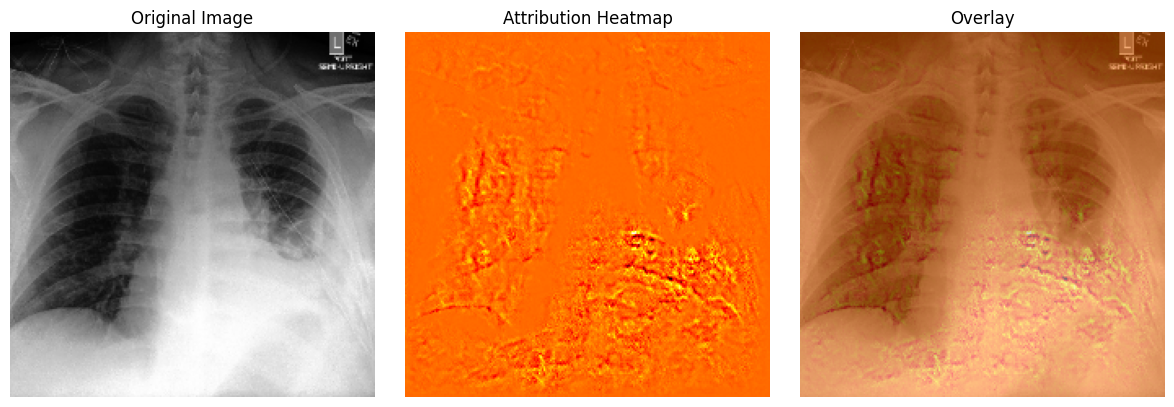

tensor(0.7976)


In [31]:
import matplotlib.pyplot as plt

def visualize_attributions(x, e, alpha=0.5):
    """
    Visualize attribution heatmaps for grayscale images.

    Args:
        x (torch.Tensor): (1, W, H) input image in [0,1]
        e (torch.Tensor): (1, W, H) attribution map in [0,1]
        alpha (float): transparency for overlay
    """

    # Ensure CPU + detach
    x = x.detach().cpu()
    e = e.detach().cpu()

    # Remove batch dim
    img = x[0].numpy()
    attr = e[0].numpy()

    # Normalize attribution safely
    attr = attr - attr.min()
    attr = attr / (attr.max() + 1e-8)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Original image
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Heatmap
    axes[1].imshow(attr, cmap="hot")
    axes[1].set_title("Attribution Heatmap")
    axes[1].axis("off")

    # Overlay
    axes[2].imshow(img, cmap="gray")
    axes[2].imshow(attr, cmap="hot", alpha=alpha)
    axes[2].set_title("Overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

i = 200
x = x_dataset[i][0]
y = x_dataset[i][1]
e = e_dataset[i][0]
visualize_attributions(x, e)
print(y)

In [32]:
class ModularCNN(nn.Module):
    def __init__(self, variant="micro", in_channels=2):
        super().__init__()

        cfgs = {
            "micro": ([8, 16], [32, 16]),
            "tiny": ([16, 32, 64], [64, 32]),
            "small": ([32, 64, 128], [128, 64]),
        }

        channels, fc = cfgs[variant]

        layers = []
        c = in_channels

        for ch in channels:
            layers += [
                nn.Conv2d(c, ch, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(ch),
                nn.ReLU(inplace=True),
            ]
            c = ch

        self.features = nn.Sequential(*layers)

        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1] * 4 * 4, fc[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(fc[0], fc[1]),
            nn.ReLU(inplace=True),
            nn.Linear(fc[1], 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x.view(-1)

In [33]:
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def split_dataset(dataset, split=0.9, seed=42):
    """
    dataset: returns (X, y_teacher_soft)
    y_teacher_hard: global hard labels aligned with dataset indices
    split: fraction for training set
    """

    global y_teacher_hard

    indices = np.arange(len(dataset))

    hard_labels = np.asarray(y_teacher_hard).reshape(-1)

    if len(hard_labels) != len(dataset):
        raise ValueError(
            f"y_teacher_hard length ({len(hard_labels)}) does not match "
            f"dataset length ({len(dataset)})"
        )

    sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=split,
        random_state=seed
    )

    train_idx, val_idx = next(sss.split(indices, hard_labels))

    return Subset(dataset, train_idx), Subset(dataset, val_idx)



def compute_metrics(y_true_soft, y_pred_soft, true_threshold=0.715):
    y_true_soft = torch.as_tensor(y_true_soft).detach().cpu().float().view(-1)
    y_pred_soft = torch.as_tensor(y_pred_soft).detach().cpu().float().view(-1)

    y_true = (y_true_soft >= true_threshold).numpy().astype(int)
    y_score = y_pred_soft.numpy()

    auc = roc_auc_score(y_true, y_score)

    thresholds = np.linspace(0, 1, 200)

    best_f1 = -1
    best_metrics = None

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)

        f1 = f1_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_metrics = {
                "threshold": float(t),
                "acc": accuracy_score(y_true, y_pred),
                "prec": precision_score(y_true, y_pred, zero_division=0),
                "rec": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1,
                "auc": auc,
            }

    return best_metrics

In [34]:
def train_one_epoch(model, loader, optim, loss_fn):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optim.zero_grad()
        logits = model(x)

        loss = loss_fn(logits, y)

        loss.backward()
        optim.step()

        total_loss += loss.item()

        # free GPU tensors immediately
        del x, y, logits

    torch.cuda.empty_cache()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    ys, ps = [], []

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        logits = model(x)
        prob = torch.sigmoid(logits).cpu()

        ys.append(y)
        ps.append(prob)

        del x, logits, prob

    y_true_soft = torch.cat(ys).numpy().flatten()
    y_pred_soft = torch.cat(ps).numpy().flatten()

    print("pred min:", y_pred_soft.min().item())
    print("pred max:", y_pred_soft.max().item())
    print("pred mean:", y_pred_soft.mean().item())
    print("pred std:", y_pred_soft.std().item())

    return compute_metrics(y_true_soft, y_pred_soft)

In [35]:
def run_experiment(dataset, name, in_channels, seed=42):
    print(f"\n===== Dataset: {name} =====")

    seed_everything(seed)

    train_ds, val_ds = split_dataset(dataset, seed=seed)

    results = {}

    for variant_idx, variant in enumerate(["micro", "tiny", "small"]):
        print(f"\n--- Model: {variant} ---")

        # Reset seed before every model initialization
        model_seed = seed + variant_idx
        seed_everything(model_seed)

        train_loader = DataLoader(
            train_ds,
            batch_size=1024,
            shuffle=True,
            pin_memory=True,
            num_workers=0,
            worker_init_fn=seed_worker,
            generator=make_generator(model_seed)
        )

        val_loader = DataLoader(
            val_ds,
            batch_size=1024,
            shuffle=False,
            pin_memory=True,
            num_workers=0,
            worker_init_fn=seed_worker,
            generator=make_generator(model_seed)
        )

        model = ModularCNN(variant, in_channels=in_channels).to(device)

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = torch.nn.BCEWithLogitsLoss()

        for epoch in range(5):
            loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
            print(f"Epoch {epoch+1} loss: {loss:.4f}")

        metrics = evaluate(model, val_loader)

        print("Metrics:", metrics)
        results[variant] = metrics

        del model
        torch.cuda.empty_cache()

    return results

In [36]:
torch.cuda.empty_cache()

In [37]:
results = {}

torch.cuda.empty_cache()
seed_everything(SEED)

results["x"] = run_experiment(x_dataset, "x_dataset", in_channels=1, seed=SEED)
results["e"] = run_experiment(e_dataset, "e_dataset", in_channels=1, seed=SEED)
results["x_e"] = run_experiment(x_e_dataset, "x_e_dataset", in_channels=2, seed=SEED)
results["x_re"] = run_experiment(x_re_dataset, "x_re_dataset", in_channels=2, seed=SEED)
results["rx_e"] = run_experiment(rx_e_dataset, "rx_e_dataset", in_channels=2, seed=SEED)

print(results)


===== Dataset: x_dataset =====

--- Model: micro ---
Epoch 1 loss: 0.6772
Epoch 2 loss: 0.6498
Epoch 3 loss: 0.6190
Epoch 4 loss: 0.5812
Epoch 5 loss: 0.5441
pred min: 0.2073647677898407
pred max: 0.8848140835762024
pred mean: 0.656287431716919
pred std: 0.16671337187290192
Metrics: {'threshold': 0.5979899497487438, 'acc': 0.78, 'prec': 0.7302533532041728, 'rec': 0.9262759924385633, 'f1': 0.8166666666666667, 'auc': np.float64(0.8855108585280884)}

--- Model: tiny ---
Epoch 1 loss: 0.6555
Epoch 2 loss: 0.5549
Epoch 3 loss: 0.5004
Epoch 4 loss: 0.4858
Epoch 5 loss: 0.4826
pred min: 0.03421488031744957
pred max: 0.9612523317337036
pred mean: 0.3745709955692291
pred std: 0.2914232909679413
Metrics: {'threshold': 0.1708542713567839, 'acc': 0.809, 'prec': 0.7734627831715211, 'rec': 0.9035916824196597, 'f1': 0.8334786399302528, 'auc': np.float64(0.9032103997848763)}

--- Model: small ---
Epoch 1 loss: 0.6382
Epoch 2 loss: 0.5138
Epoch 3 loss: 0.4880
Epoch 4 loss: 0.4779
Epoch 5 loss: 0.4724
